In [370]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans


## Loading dataset

In [371]:
# 📂 Load Data
file_path = "pharma_realistic_10000.csv"
df = pd.read_csv(file_path)

print("✅ Data Loaded:", df.shape)


df.head()

✅ Data Loaded: (10000, 20)


,id,active_ingredient,brand_name,manufacturer,therapeutic_group,pharmacological_class,drug_type,strength,dosage_form,route,indication,indication_category,side_effects,pregnancy_category,controlled_substance,otc_or_rx,food_interaction,alcohol_interaction,num_ingredients,is_combination_drug
0,1,Amoxicillin + Clavulanate,Augmentin,GSK,Antibiotic,Beta-lactam + Beta-lactamase inhibitor,Small molecule,1000 mg,Syrup,Oral,Infection,Infectious,Nausea,B,No,RX,0,0,2,1
1,2,Omeprazole,Seclo,AstraZeneca,Antacid,Proton pump inhibitor,Small molecule,10 mg,Capsule,Oral,Peptic ulcer,Gastrointestinal,Headache,C,No,OTC,1,0,1,0
2,3,Azithromycin,Azit,Incepta,Antibiotic,Macrolide,Small molecule,250 mg,Tablet,Oral,Respiratory infection,Infectious,Abdominal pain,B,No,RX,0,0,1,0
3,4,Salbutamol,Brodil,GSK,Bronchodilator,Beta-2 agonist,Small molecule,2 mg,Syrup,Oral,COPD,Respiratory,Headache,C,No,RX,0,0,1,0
4,5,Lisinopril,Listril,AstraZeneca,Antihypertensive,ACE inhibitor,Small molecule,10 mg,Tablet,Oral,Post-MI,Cardiovascular,Hyperkalemia,D,No,RX,0,1,1,0


In [372]:
df.tail()

,id,active_ingredient,brand_name,manufacturer,therapeutic_group,pharmacological_class,drug_type,strength,dosage_form,route,indication,indication_category,side_effects,pregnancy_category,controlled_substance,otc_or_rx,food_interaction,alcohol_interaction,num_ingredients,is_combination_drug
9995,9996,Insulin Glargine,Lantus,Incepta,Antidiabetic,Long-acting insulin,Biologic,300 IU/ml,Injection,Subcutaneous,Type 2 diabetes,Endocrine,Hypoglycemia,C,No,RX,1,1,1,0
9996,9997,Amoxicillin + Clavulanate,Augmentin,GSK,Antibiotic,Beta-lactam + Beta-lactamase inhibitor,Small molecule,375 mg,Tablet,Oral,Infection,Infectious,Nausea,B,No,RX,0,0,2,1
9997,9998,Paracetamol,Panadol,Renata,Analgesic,Para-aminophenol,Small molecule,250 mg/5ml,Tablet,Oral,Pain,General,Nausea,A,No,OTC,0,1,1,0
9998,9999,Ibuprofen,Profen,ACI,Analgesic,NSAID,Small molecule,200 mg,Tablet,Oral,Pain,General,Gastric irritation,D,No,OTC,1,1,1,0
9999,10000,Azithromycin,Zithromax,Incepta,Antibiotic,Macrolide,Small molecule,250 mg,Capsule,Oral,Infection,Infectious,Vomiting,B,No,RX,0,0,1,0


In [373]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     10000 non-null  int64 
 1   active_ingredient      10000 non-null  object
 2   brand_name             10000 non-null  object
 3   manufacturer           10000 non-null  object
 4   therapeutic_group      10000 non-null  object
 5   pharmacological_class  10000 non-null  object
 6   drug_type              10000 non-null  object
 7   strength               10000 non-null  object
 8   dosage_form            10000 non-null  object
 9   route                  10000 non-null  object
 10  indication             10000 non-null  object
 11  indication_category    10000 non-null  object
 12  side_effects           10000 non-null  object
 13  pregnancy_category     10000 non-null  object
 14  controlled_substance   10000 non-null  object
 15  otc_or_rx           

In [374]:
df.describe()

,id,food_interaction,alcohol_interaction,num_ingredients,is_combination_drug
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,0.47200,0.665900,1.065600,0.065600
std,2886.89568,0.49924,0.471698,0.247594,0.247594
min,1.00000,0.00000,0.000000,1.000000,0.000000
25%,2500.75000,0.00000,0.000000,1.000000,0.000000
50%,5000.50000,0.00000,1.000000,1.000000,0.000000
75%,7500.25000,1.00000,1.000000,1.000000,0.000000
max,10000.00000,1.00000,1.000000,2.000000,1.000000


In [375]:
df.isnull().sum()

id                       0
active_ingredient        0
brand_name               0
manufacturer             0
therapeutic_group        0
pharmacological_class    0
drug_type                0
strength                 0
dosage_form              0
route                    0
indication               0
indication_category      0
side_effects             0
pregnancy_category       0
controlled_substance     0
otc_or_rx                0
food_interaction         0
alcohol_interaction      0
num_ingredients          0
is_combination_drug      0
dtype: int64

In [376]:
df.duplicated().sum()

0

In [377]:
df.dtypes

id                        int64
active_ingredient        object
brand_name               object
manufacturer             object
therapeutic_group        object
pharmacological_class    object
drug_type                object
strength                 object
dosage_form              object
route                    object
indication               object
indication_category      object
side_effects             object
pregnancy_category       object
controlled_substance     object
otc_or_rx                object
food_interaction          int64
alcohol_interaction       int64
num_ingredients           int64
is_combination_drug       int64
dtype: object

In [378]:
df.shape

(10000, 20)

In [379]:
df.columns

Index(['id', 'active_ingredient', 'brand_name', 'manufacturer',
       'therapeutic_group', 'pharmacological_class', 'drug_type', 'strength',
       'dosage_form', 'route', 'indication', 'indication_category',
       'side_effects', 'pregnancy_category', 'controlled_substance',
       'otc_or_rx', 'food_interaction', 'alcohol_interaction',
       'num_ingredients', 'is_combination_drug'],
      dtype='object')

In [380]:
df.nunique()

id                       10000
active_ingredient           15
brand_name                  61
manufacturer                15
therapeutic_group            9
pharmacological_class       15
drug_type                    2
strength                    27
dosage_form                  5
route                        4
indication                  32
indication_category          7
side_effects                25
pregnancy_category           5
controlled_substance         1
otc_or_rx                    2
food_interaction             2
alcohol_interaction          2
num_ingredients              2
is_combination_drug          2
dtype: int64

EDA

In [381]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

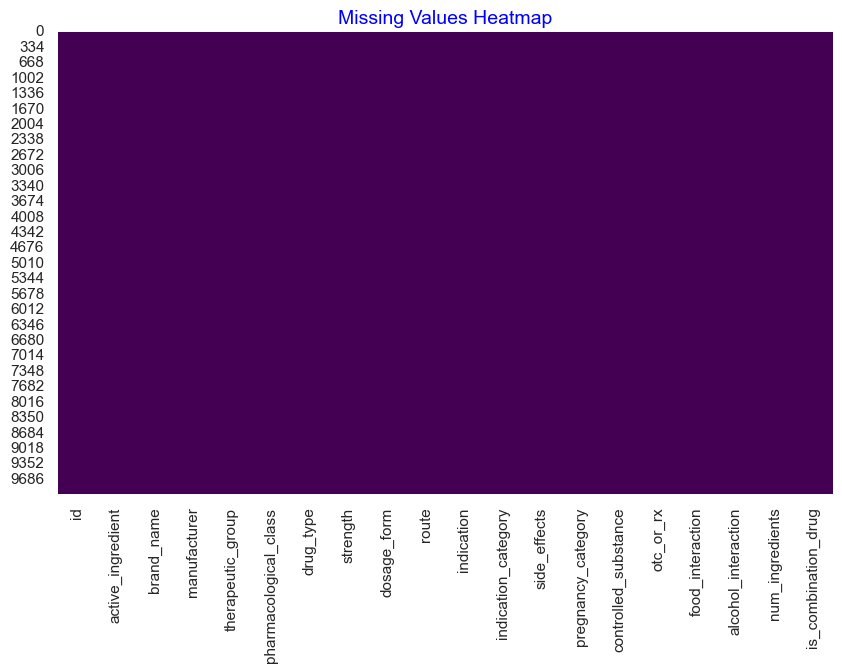

In [382]:
plt.figure()
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap", fontsize=14, color='blue')
plt.show()

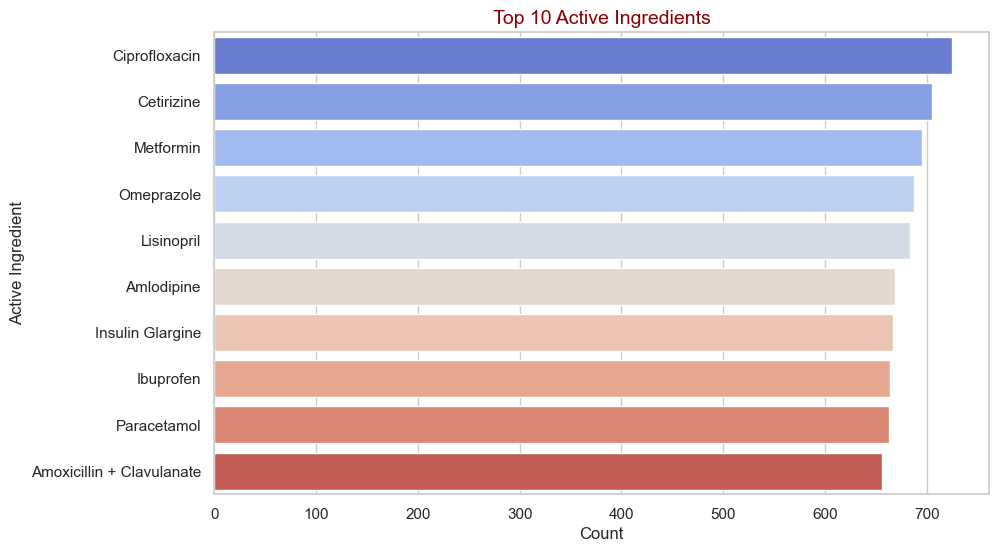

In [383]:
top_ing = df['active_ingredient'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_ing.values, y=top_ing.index, palette='coolwarm')
plt.title("Top 10 Active Ingredients", fontsize=14, color='darkred')
plt.xlabel("Count")
plt.ylabel("Active Ingredient")
plt.show()

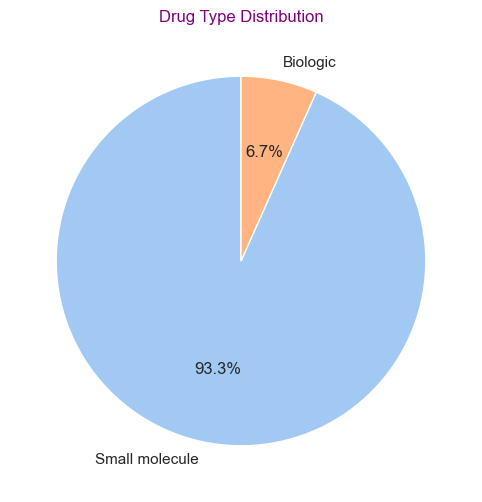

In [384]:
plt.figure()
df['drug_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)
plt.title("Drug Type Distribution", color='purple')
plt.ylabel('')
plt.show()

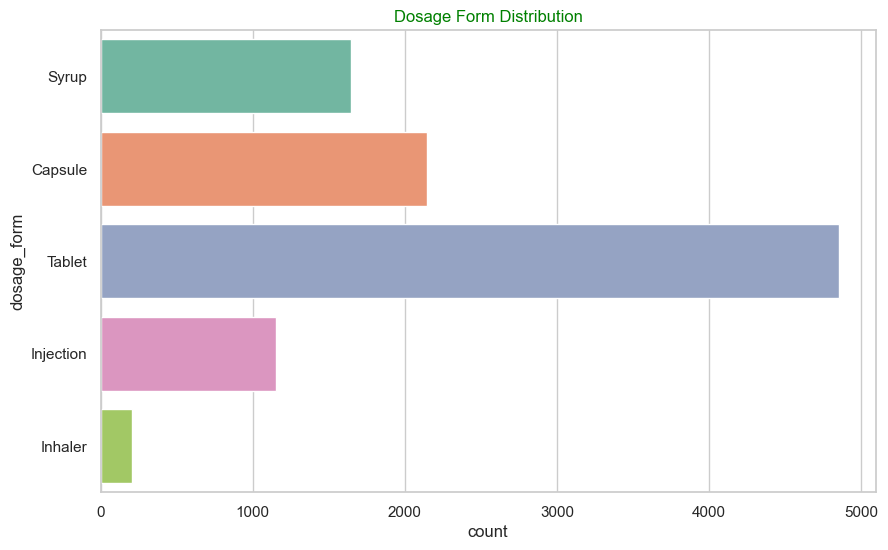

In [385]:
plt.figure()
sns.countplot(data=df, y='dosage_form', palette='Set2')
plt.title("Dosage Form Distribution", color='green')
plt.show()

#define and distribute different form.

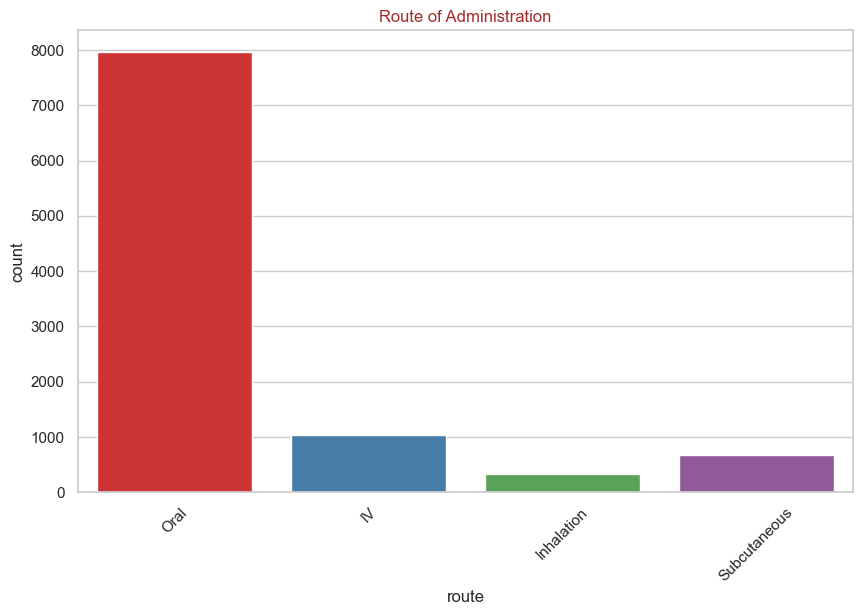

In [386]:
plt.figure()
sns.countplot(data=df, x='route', palette='Set1')
plt.title("Route of Administration", color='brown')
plt.xticks(rotation=45)
plt.show()

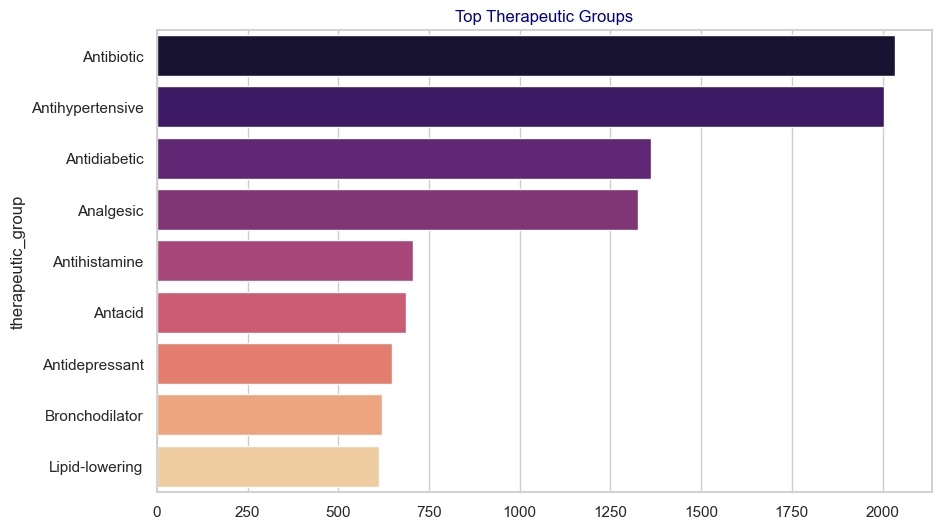

In [387]:
top_therapeutic = df['therapeutic_group'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_therapeutic.values, y=top_therapeutic.index, palette='magma')
plt.title("Top Therapeutic Groups", color='darkblue')
plt.show()

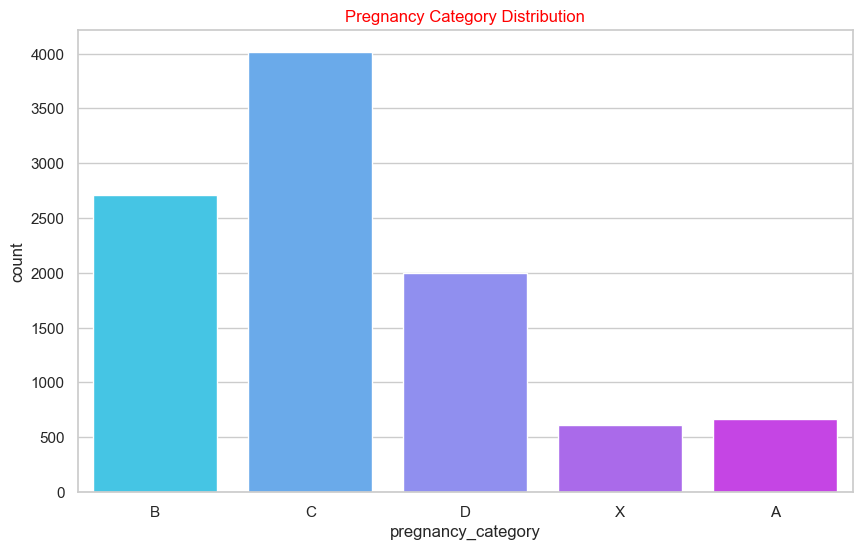

In [388]:
plt.figure()
sns.countplot(data=df, x='pregnancy_category', palette='cool')
plt.title("Pregnancy Category Distribution", color='red')
plt.show()

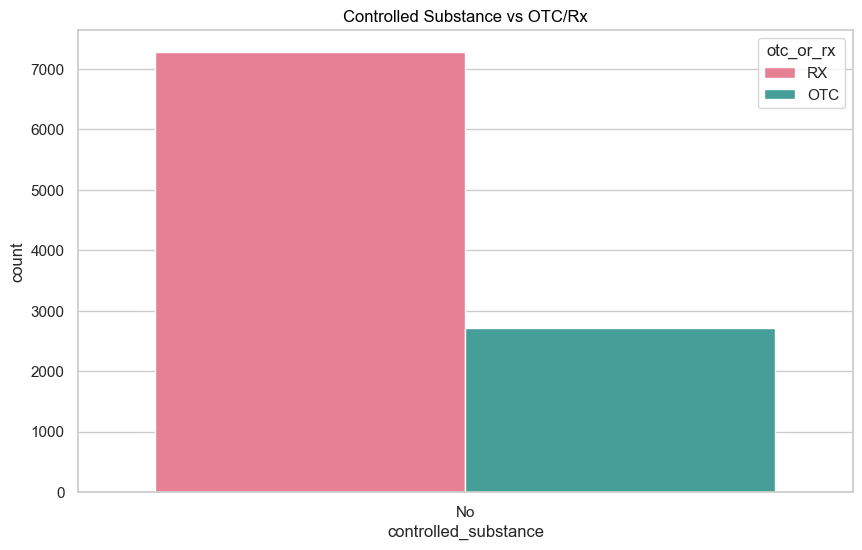

In [389]:
plt.figure()
sns.countplot(data=df, x='controlled_substance', hue='otc_or_rx', palette='husl')
plt.title("Controlled Substance vs OTC/Rx", color='black')
plt.show()

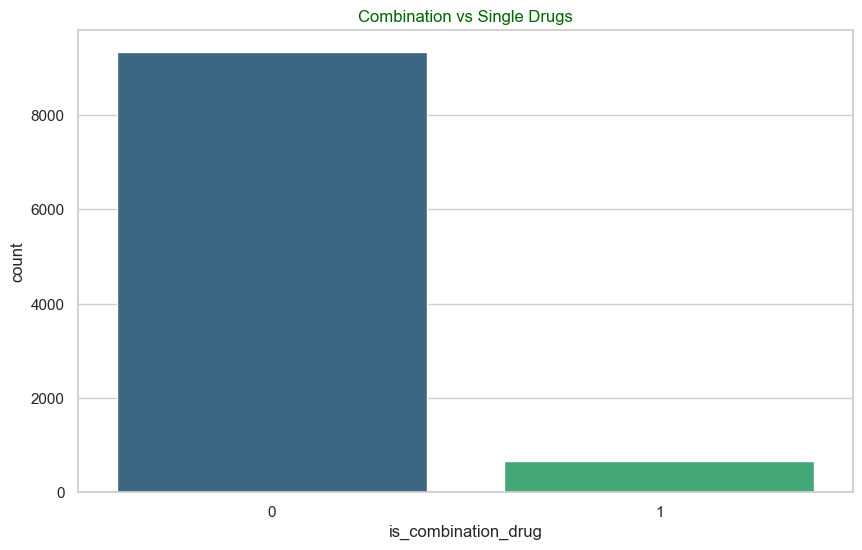

In [390]:
plt.figure()
sns.countplot(data=df, x='is_combination_drug', palette='viridis')
plt.title("Combination vs Single Drugs", color='darkgreen')
plt.show()

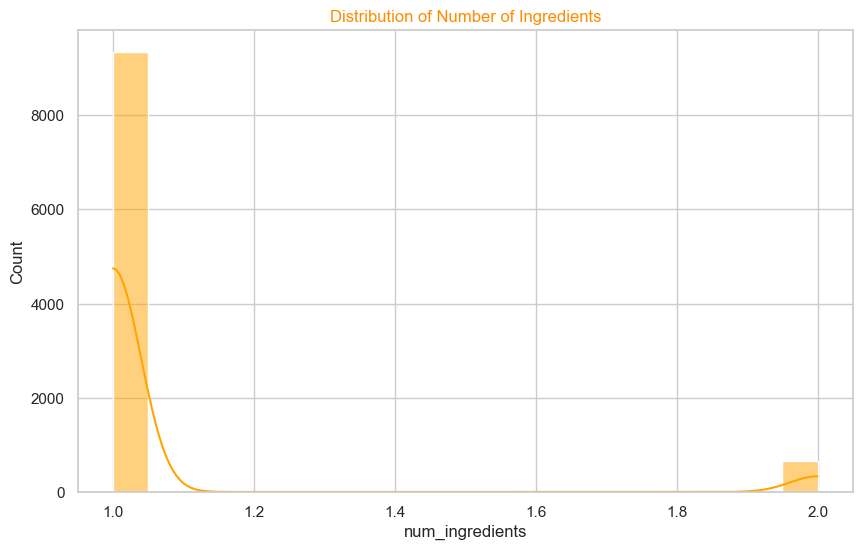

In [391]:
plt.figure()
sns.histplot(df['num_ingredients'], bins=20, kde=True, color='orange')
plt.title("Distribution of Number of Ingredients", color='darkorange')
plt.show()

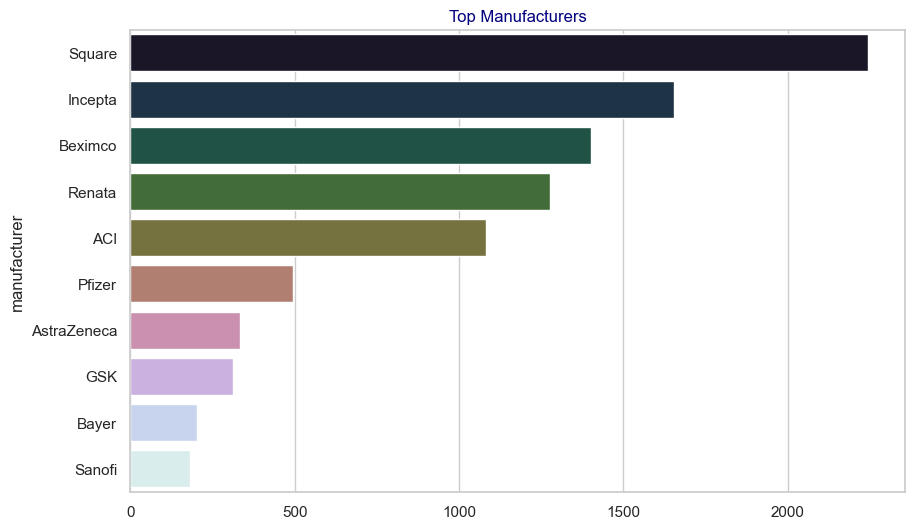

In [392]:
top_manu = df['manufacturer'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_manu.values, y=top_manu.index, palette='cubehelix')
plt.title("Top Manufacturers", color='navy')
plt.show()

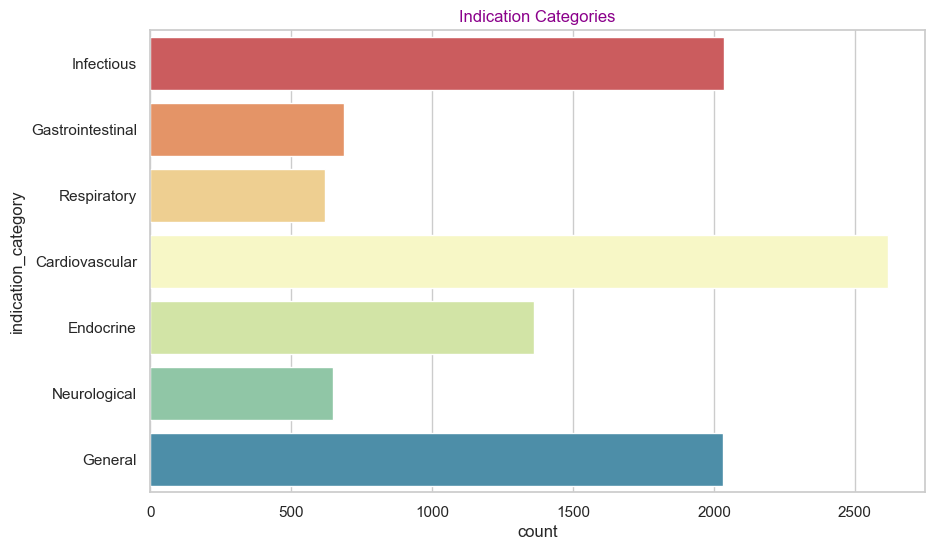

In [393]:
plt.figure()
sns.countplot(data=df, y='indication_category', palette='Spectral')
plt.title("Indication Categories", color='darkmagenta')
plt.show()

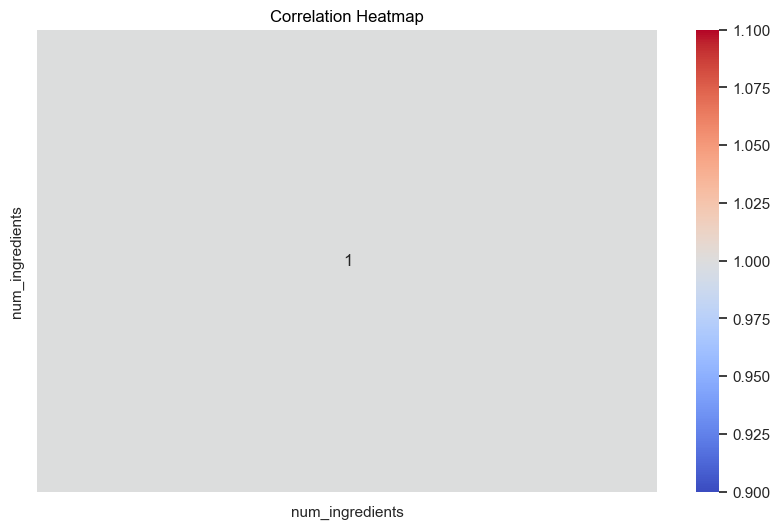

In [394]:
plt.figure()
sns.heatmap(df[['num_ingredients']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap", color='black')
plt.show()

  Therapeutic Group - Frequency Table
                   Count  Percentage(%)
therapeutic_group                      
Antibiotic          2034          20.34
Antihypertensive    2005          20.05
Antidiabetic        1362          13.62
Analgesic           1327          13.27
Antihistamine        705           7.05
Antacid              687           6.87
Antidepressant       647           6.47
Bronchodilator       620           6.20
Lipid-lowering       613           6.13

Total: 10000 rows  |  Categories: 9


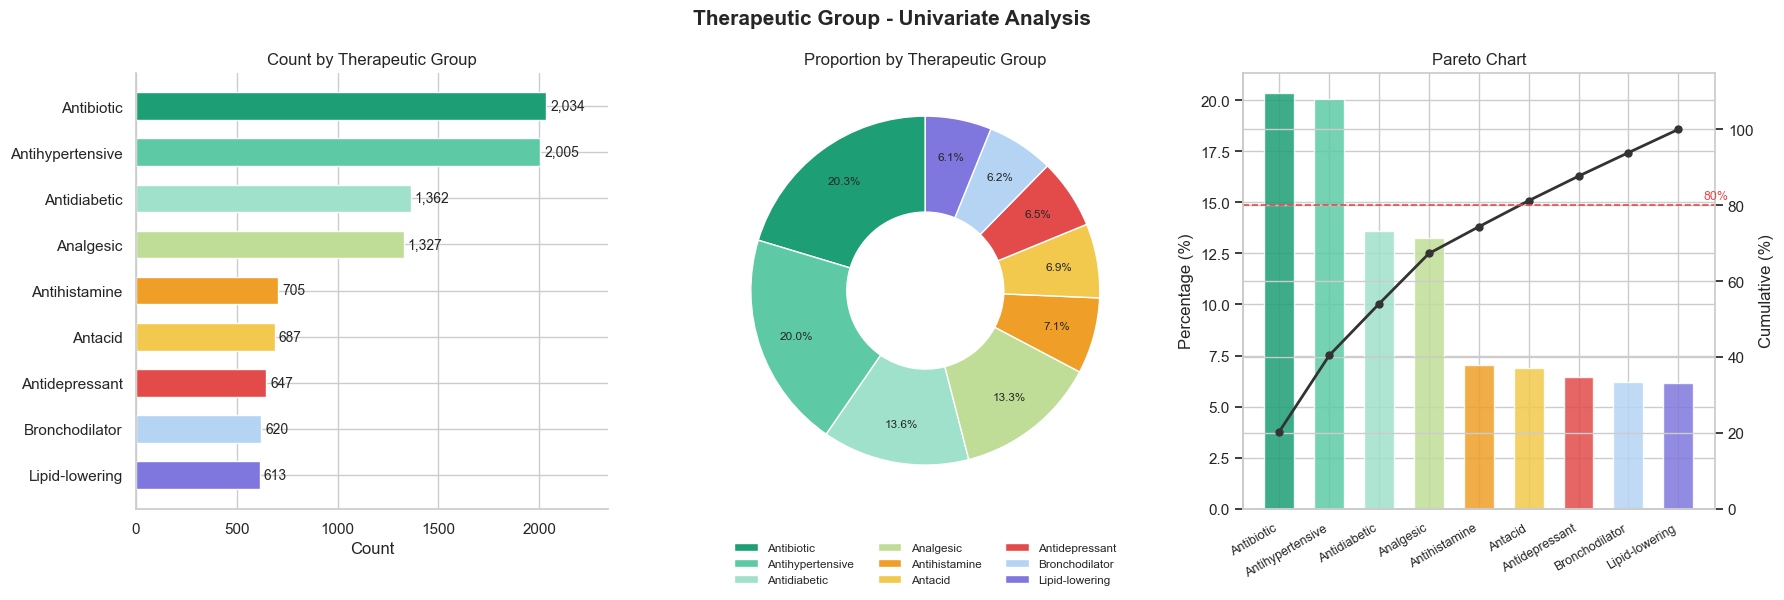

In [395]:
# ── 1. 频率统计 ──────────────────────────────────────────
counts = df['therapeutic_group'].value_counts()
pct    = df['therapeutic_group'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count': counts,
    'Percentage(%)': pct.round(2)
})
print("=" * 40)
print("  Therapeutic Group - Frequency Table")
print("=" * 40)
print(summary.to_string())
print(f"\nTotal: {counts.sum()} rows  |  Categories: {len(counts)}")

# ── 2. 颜色 ──────────────────────────────────────────────
colors = [
    '#1D9E75','#5DCAA5','#9FE1CB','#C0DD97',
    '#EF9F27','#F2C94C','#E24B4A','#B5D4F4','#7F77DD'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Therapeutic Group - Univariate Analysis', fontsize=15, fontweight='bold')

# ── 图1：条形图 ───────────────────────────────────────────
ax1 = axes[0]
bars = ax1.barh(counts.index[::-1], counts.values[::-1],
                color=colors[::-1], height=0.6)
for bar, val in zip(bars, counts.values[::-1]):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=10)
ax1.set_xlabel('Count')
ax1.set_title('Count by Therapeutic Group')
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_xlim(0, counts.max() * 1.15)

# ── 图2：环形图 ───────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=None,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55)
)
for at in autotexts:
    at.set_fontsize(8.5)
ax2.legend(
    wedges, counts.index,
    loc='lower center', bbox_to_anchor=(0.5, -0.2),
    ncol=3, fontsize=8.5, frameon=False
)
ax2.set_title('Proportion by Therapeutic Group')

# ── 图3：帕累托图 ─────────────────────────────────────────
ax3 = axes[2]
cumulative = pct.cumsum()
x = range(len(counts))
ax3.bar(x, pct.values, color=colors, width=0.6, alpha=0.85)
ax3_twin = ax3.twinx()
ax3_twin.plot(x, cumulative.values, color='#333', marker='o',
              markersize=5, linewidth=2)
ax3_twin.axhline(y=80, color='#E24B4A', linestyle='--', linewidth=1.2)
ax3_twin.text(len(counts) - 0.5, 81.5, '80%', color='#E24B4A', fontsize=9)
ax3_twin.set_ylabel('Cumulative (%)')
ax3_twin.set_ylim(0, 115)
ax3.set_xticks(x)
ax3.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=9)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Pareto Chart')
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('therapeutic_group_EDA.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature engineering


In [396]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('pharma_realistic_10000.csv')

# ── 1. Label Encoding─────────────────────────

# pregnancy_category: A=0 B=1 C=2 D=3 X=4
pregnancy_order = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'X': 4}
df['pregnancy_category_encoded'] = df['pregnancy_category'].map(pregnancy_order)

# otc_or_rx: OTC=0  RX=1
df['otc_or_rx_encoded'] = df['otc_or_rx'].map({'OTC': 0, 'RX': 1})

# drug_type: Only two data so automatically handled with these LabelEncoder
le = LabelEncoder()
df['drug_type_encoded'] = le.fit_transform(df['drug_type'])
print("drug_type mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


# ── 2. One-Hot Encoding（无顺序多类别列）────────────────────────

ohe_cols = [
    'therapeutic_group',   # 9 types
    'dosage_form',         # 5 types
    'route',               # 4 types
    'indication_category', # 7 types
    'manufacturer',        # 15 types
]

df_encoded = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, drop_first=False)

print("\nShape before encoding:", df.shape)
print("Shape after  encoding:", df_encoded.shape)


# ── 3. Delete the unnecessary list. ───────────────────

drop_cols = [
    'product_id' if 'product_id' in df.columns else None,
    'brand_name',
    'active_ingredient',
    'pharmacological_class',
    'indication',
    'side_effects',
    'strength',
    'pregnancy_category',  
    'otc_or_rx',           
    'drug_type',           
]
drop_cols = [c for c in drop_cols if c and c in df_encoded.columns]
df_encoded.drop(columns=drop_cols, inplace=True)

print("\nFinal columns:")
print(df_encoded.columns.tolist())
print("\nFinal shape:", df_encoded.shape)


# ── 4. precast teh result ──────────────────────────────────────────────────

print("\nSample output:")
print(df_encoded.head(3).to_string())


# ── 5. Save the encoded dataset ────────────────────────────────────────

df_encoded.to_csv('pharma_encoded.csv', index=False)
print("\nSaved as pharma_encoded.csv")

drug_type mapping: {'Biologic': 0, 'Small molecule': 1}

Shape before encoding: (10000, 23)
Shape after  encoding: (10000, 58)

Final columns:
['id', 'controlled_substance', 'food_interaction', 'alcohol_interaction', 'num_ingredients', 'is_combination_drug', 'pregnancy_category_encoded', 'otc_or_rx_encoded', 'drug_type_encoded', 'therapeutic_group_Analgesic', 'therapeutic_group_Antacid', 'therapeutic_group_Antibiotic', 'therapeutic_group_Antidepressant', 'therapeutic_group_Antidiabetic', 'therapeutic_group_Antihistamine', 'therapeutic_group_Antihypertensive', 'therapeutic_group_Bronchodilator', 'therapeutic_group_Lipid-lowering', 'dosage_form_Capsule', 'dosage_form_Inhaler', 'dosage_form_Injection', 'dosage_form_Syrup', 'dosage_form_Tablet', 'route_IV', 'route_Inhalation', 'route_Oral', 'route_Subcutaneous', 'indication_category_Cardiovascular', 'indication_category_Endocrine', 'indication_category_Gastrointestinal', 'indication_category_General', 'indication_category_Infectious', 'ind

Still object columns: ['controlled_substance']
All columns now numeric.

Feature count : 48
Target balance:
otc_or_rx_encoded
RX     7281
OTC    2719
Name: count, dtype: int64

Train: 8000  |  Test: 2000

── Random Forest ──
Accuracy : 1.0000
F1 Score : 1.0000
              precision    recall  f1-score   support

         OTC       1.00      1.00      1.00       544
          RX       1.00      1.00      1.00      1456

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


── Logistic Regression ──
Accuracy : 1.0000
F1 Score : 1.0000
              precision    recall  f1-score   support

         OTC       1.00      1.00      1.00       544
          RX       1.00      1.00      1.00      1456

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



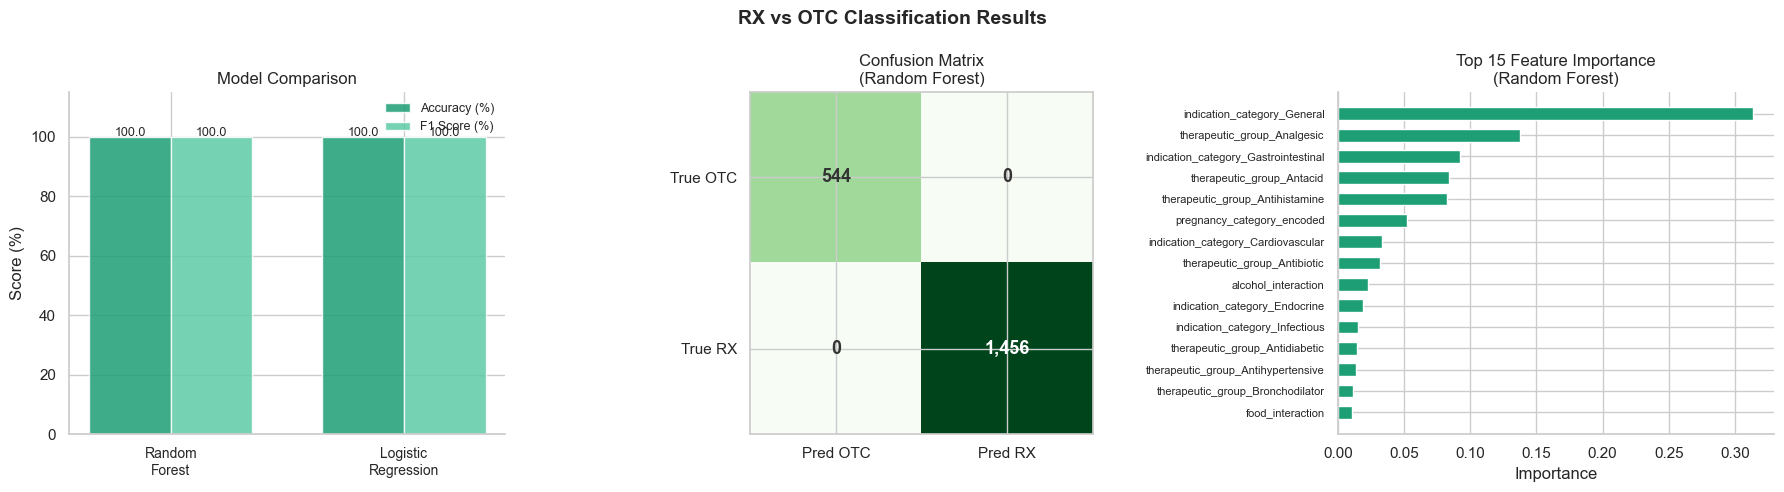


Saved as rx_classification_results.png


In [400]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Load data ─────────────────────────────────────────────────
df = pd.read_csv('pharma_encoded.csv')

# ── 2. Convert remaining object columns to numeric ───────────────
obj_cols = df.select_dtypes(include='object').columns.tolist()
print("Still object columns:", obj_cols)

le = LabelEncoder()
for col in obj_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("All columns now numeric.")

# ── 3. Define features and target ───────────────────────────────
target = 'otc_or_rx_encoded'
X = df.drop(columns=[target])
y = df[target]

print(f"\nFeature count : {X.shape[1]}")
print("Target balance:")
print(y.value_counts().rename({0: 'OTC', 1: 'RX'}))

# ── 4. Train / test split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")

# ── 5. Train models ──────────────────────────────────────────────
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'cm':       confusion_matrix(y_test, y_pred),
    }
    print(f"\n── {name} ──")
    print(f"Accuracy : {results[name]['accuracy']:.4f}")
    print(f"F1 Score : {results[name]['f1']:.4f}")
    print(classification_report(y_test, y_pred, target_names=['OTC', 'RX']))

# ── 6. Visualize results ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RX vs OTC Classification Results', fontsize=14, fontweight='bold')

# Chart 1: Model comparison bar chart
ax1 = axes[0]
model_names = list(results.keys())
acc_vals = [results[n]['accuracy'] * 100 for n in model_names]
f1_vals  = [results[n]['f1'] * 100       for n in model_names]
x = np.arange(len(model_names))
w = 0.35
b1 = ax1.bar(x - w/2, acc_vals, w, label='Accuracy (%)', color='#1D9E75', alpha=0.85)
b2 = ax1.bar(x + w/2, f1_vals,  w, label='F1 Score (%)', color='#5DCAA5', alpha=0.85)
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}', ha='center', fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(['Random\nForest', 'Logistic\nRegression'], fontsize=10)
ax1.set_ylim(0, 115)
ax1.set_ylabel('Score (%)')
ax1.set_title('Model Comparison')
ax1.legend(fontsize=9, frameon=False)
ax1.spines[['top', 'right']].set_visible(False)

# Chart 2: Confusion matrix for Random Forest
ax2 = axes[1]
cm = results['Random Forest']['cm']
ax2.imshow(cm, cmap='Greens')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Pred OTC', 'Pred RX'])
ax2.set_yticklabels(['True OTC', 'True RX'])
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                 fontsize=13, fontweight='bold',
                 color='white' if cm[i,j] > cm.max()/2 else '#333')
ax2.set_title('Confusion Matrix\n(Random Forest)')

# Chart 3: Top 15 feature importances from Random Forest
ax3 = axes[2]
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()
ax3.barh(top15.index, top15.values, color='#1D9E75', height=0.6)
ax3.set_xlabel('Importance')
ax3.set_title('Top 15 Feature Importance\n(Random Forest)')
ax3.spines[['top', 'right']].set_visible(False)
ax3.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('rx_classification_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as rx_classification_results.png")